# Car Price Prediction with Machine Learning
## Regression Model to Predict Used Car Selling Prices

**Objective:** Build regression models that predict the selling price of a used car based on features like brand, age, mileage, fuel type, and transmission.

**Tech Stack:** Python, pandas, scikit-learn, matplotlib, seaborn

**Dataset:** [Vehicle dataset from cardekho](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho) (Kaggle)

---

In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("done !")

done !


In [2]:

import os

possible_files = [
    'car data.csv',
    'CAR DETAILS FROM CAR DEKHO.csv',
    'Car details v3.csv',
    'cardekho.csv',
    'car_data.csv'
]

df = None
loaded_file = None

for fname in possible_files:
    if os.path.exists(fname):
        df = pd.read_csv(fname)
        loaded_file = fname
        print(f" Loaded: {fname}")
        break

if df is None:
    csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
    print(" Could not find the dataset CSV.")
    print(f"   CSV files in this folder: {csv_files}")
else:
    print(f"\nDataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"\nColumns: {df.columns.tolist()}")

 Loaded: car data.csv

Dataset shape: 301 rows × 9 columns

Columns: ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']


In [3]:

print("=== FIRST 5 ROWS ===")
display(df.head())

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== BASIC INFO ===")
df.info()

=== FIRST 5 ROWS ===


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0



=== DATA TYPES ===
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

=== BASIC INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [5]:

print("=== NULL VALUE COUNTS ===")
null_counts = df.isnull().sum()
print(null_counts)
print(f"\nTotal nulls: {null_counts.sum()}")

print("\n=== NULL PERCENTAGE ===")
print((df.isnull().sum() / len(df) * 100).round(2))

print(f"\n=== DUPLICATE ROWS ===")
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

if duplicates > 0:
    print(f"    {duplicates} ")
else:
    print("   No duplicate rows found.")

=== NULL VALUE COUNTS ===
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Total nulls: 0

=== NULL PERCENTAGE ===
Car_Name         0.0
Year             0.0
Selling_Price    0.0
Present_Price    0.0
Kms_Driven       0.0
Fuel_Type        0.0
Seller_Type      0.0
Transmission     0.0
Owner            0.0
dtype: float64

=== DUPLICATE ROWS ===
Duplicate rows: 2
    2 


In [6]:

df_clean = df.copy()

df_clean.columns = df_clean.columns.str.strip().str.lower().str.replace(' ', '_')
print("Cleaned column names:")
print(df_clean.columns.tolist())

for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = df_clean[col].str.strip()

rename_map = {}
for col in df_clean.columns:
    if col in ['selling_price', 'price', 'sellingprice']:
        rename_map[col] = 'selling_price'
    elif col in ['present_price', 'ex_showroom_price', 'current_price']:
        rename_map[col] = 'present_price'
    elif col in ['year']:
        rename_map[col] = 'year'
    elif 'km' in col or 'driven' in col:
        rename_map[col] = 'km_driven'
    elif col in ['fuel', 'fuel_type']:
        rename_map[col] = 'fuel_type'
    elif col in ['seller_type', 'seller']:
        rename_map[col] = 'seller_type'
    elif col in ['transmission']:
        rename_map[col] = 'transmission'
    elif col in ['owner', 'owners']:
        rename_map[col] = 'owner'
    elif 'name' in col or 'car' in col:
        rename_map[col] = 'car_name'

df_clean = df_clean.rename(columns=rename_map)
print(f"\nRenamed columns: {df_clean.columns.tolist()}")

before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f"\nRemoved {before - after} duplicate rows. Shape: {df_clean.shape}")

if df_clean.isnull().sum().sum() > 0:
    print(f"\nNull values found:")
    print(df_clean.isnull().sum())
    df_clean = df_clean.dropna()
    print(f"Shape after dropping nulls: {df_clean.shape}")
else:
    print("\n No null values found.")

if 'fuel_type' in df_clean.columns:
    df_clean['fuel_type'] = df_clean['fuel_type'].str.capitalize(
    print(f"\nFuel types: {df_clean['fuel_type'].unique()}")

if 'transmission' in df_clean.columns:
    df_clean['transmission'] = df_clean['transmission'].str.capitalize()
    print(f"Transmission types: {df_clean['transmission'].unique()}")

if 'seller_type' in df_clean.columns:
    df_clean['seller_type'] = df_clean['seller_type'].str.capitalize()
    print(f"Seller types: {df_clean['seller_type'].unique()}")

print(f"\n shape: {df_clean.shape}")

Cleaned column names:
['car_name', 'year', 'selling_price', 'present_price', 'kms_driven', 'fuel_type', 'seller_type', 'transmission', 'owner']

Renamed columns: ['car_name', 'year', 'selling_price', 'present_price', 'km_driven', 'fuel_type', 'seller_type', 'transmission', 'owner']

Removed 2 duplicate rows. Shape: (299, 9)

 No null values found.

Fuel types: ['Petrol' 'Diesel' 'Cng']
Transmission types: ['Manual' 'Automatic']
Seller types: ['Dealer' 'Individual']

 shape: (299, 9)


In [7]:

if 'year' in df_clean.columns:
    current_year = 2020  # Dataset is from around 2020; adjust if needed
    df_clean['car_age'] = current_year - df_clean['year']
    print(f"Created 'car_age' (based on year {current_year})")
    print(f"Age range: {df_clean['car_age'].min()} to {df_clean['car_age'].max()} years")
else:
    print(" No 'year' column ")

if 'car_name' in df_clean.columns:
    df_clean['brand'] = df_clean['car_name'].apply(lambda x: str(x).split()[0] if pd.notna(x) else 'Unknown')
    df_clean['brand'] = df_clean['brand'].str.capitalize()
    print(f"\nCreated 'brand' from car name")
    print(f"Top 10 brands:")
    print(df_clean['brand'].value_counts().head(10))
else:
    print(" No 'car_name' column ")

print("\n=== ENGINEERED FEATURES ===")
print(df_clean[['car_name', 'brand', 'year', 'car_age']].head(10).to_string(index=False))

Created 'car_age' (based on year 2020)
Age range: 2 to 17 years

Created 'brand' from car name
Top 10 brands:
brand
City        26
Bajaj       25
Corolla     17
Royal       17
Honda       17
Hero        15
Verna       14
Etios       11
Fortuner    10
Brio        10
Name: count, dtype: int64

=== ENGINEERED FEATURES ===
     car_name  brand  year  car_age
         ritz   Ritz  2014        6
          sx4    Sx4  2013        7
         ciaz   Ciaz  2017        3
      wagon r  Wagon  2011        9
        swift  Swift  2014        6
vitara brezza Vitara  2018        2
         ciaz   Ciaz  2015        5
      s cross      S  2015        5
         ciaz   Ciaz  2016        4
         ciaz   Ciaz  2015        5


In [8]:

print("=== NUMERIC COLUMNS ===")
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
print(df_clean[numeric_cols].describe().round(2))

print("\n=== CATEGORICAL COLUMNS ===")
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    print(f"\n{col}: {df_clean[col].nunique()} unique values")
    print(df_clean[col].value_counts().head(5))

=== NUMERIC COLUMNS ===
          year  selling_price  present_price  km_driven   owner  car_age
count   299.00         299.00         299.00     299.00  299.00   299.00
mean   2013.62           4.59           7.54   36916.75    0.04     6.38
std       2.90           4.98           8.57   39015.17    0.25     2.90
min    2003.00           0.10           0.32     500.00    0.00     2.00
25%    2012.00           0.85           1.20   15000.00    0.00     4.00
50%    2014.00           3.51           6.10   32000.00    0.00     6.00
75%    2016.00           6.00           9.84   48883.50    0.00     8.00
max    2018.00          35.00          92.60  500000.00    3.00    17.00

=== CATEGORICAL COLUMNS ===

car_name: 98 unique values
car_name
city             26
corolla altis    16
verna            14
brio             10
fortuner         10
Name: count, dtype: int64

fuel_type: 3 unique values
fuel_type
Petrol    239
Diesel     58
Cng         2
Name: count, dtype: int64

seller_type: 2 uniqu

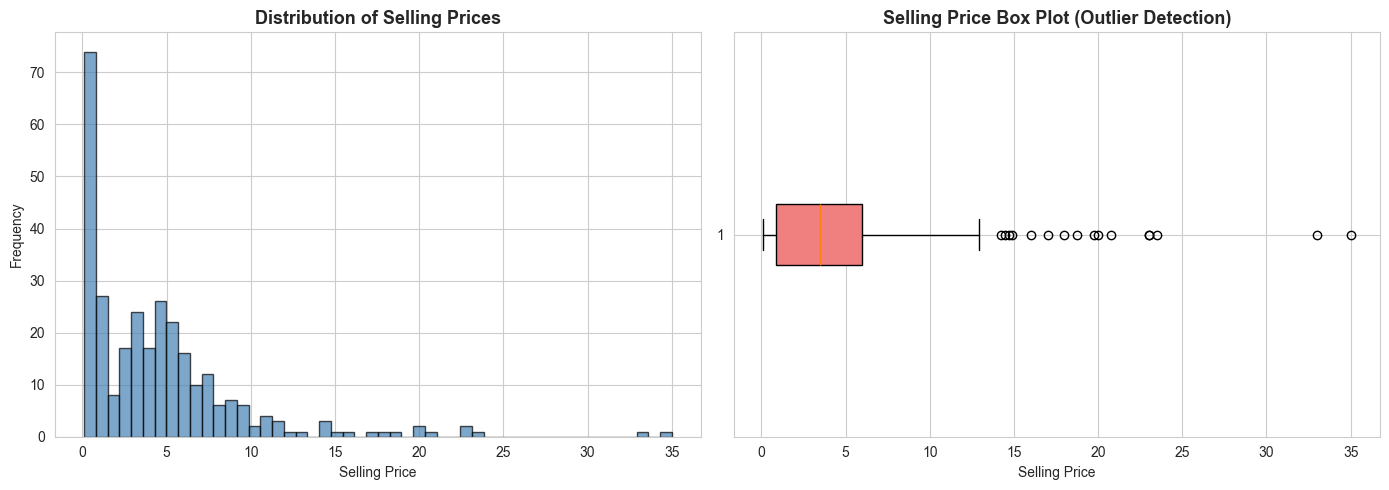


Price statistics:
  Mean:   ₹5
  Median: ₹4
  Min:    ₹0
  Max:    ₹35

 Most cars are in the lower price range. Right-skewed distribution suggests outliers (luxury cars).


In [9]:

if 'selling_price' in df_clean.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(df_clean['selling_price'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0].set_title('Distribution of Selling Prices', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Selling Price')
    axes[0].set_ylabel('Frequency')

    axes[1].boxplot(df_clean['selling_price'], vert=False, patch_artist=True,
                    boxprops=dict(facecolor='lightcoral'))
    axes[1].set_title('Selling Price Box Plot (Outlier Detection)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Selling Price')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nPrice statistics:")
    print(f"  Mean:   ₹{df_clean['selling_price'].mean():,.0f}")
    print(f"  Median: ₹{df_clean['selling_price'].median():,.0f}")
    print(f"  Min:    ₹{df_clean['selling_price'].min():,.0f}")
    print(f"  Max:    ₹{df_clean['selling_price'].max():,.0f}")
    
    print("\n Most cars are in the lower price range. Right-skewed distribution suggests outliers (luxury cars).")
else:
    print(" 'selling_price' column not found.")

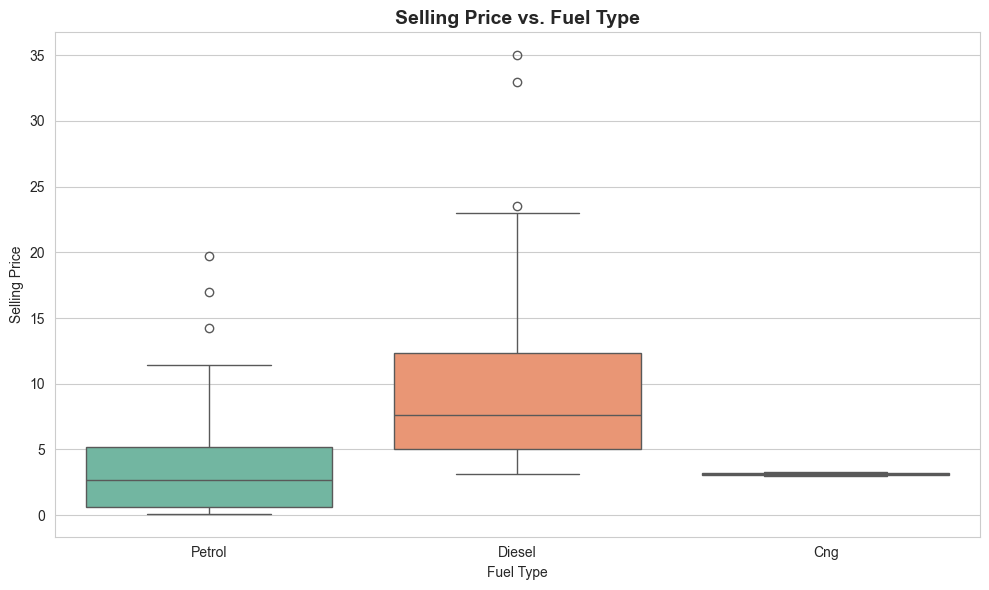

=== AVERAGE PRICE BY FUEL TYPE ===
           mean  median  count
fuel_type                     
Cng         3.0     3.0      2
Diesel     10.0     8.0     58
Petrol      3.0     3.0    239

 Diesel cars often sell for higher prices due to better fuel efficiency and torque.


In [10]:

if 'fuel_type' in df_clean.columns and 'selling_price' in df_clean.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_clean, x='fuel_type', y='selling_price', palette='Set2')
    plt.title('Selling Price vs. Fuel Type', fontsize=14, fontweight='bold')
    plt.xlabel('Fuel Type')
    plt.ylabel('Selling Price')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print("=== AVERAGE PRICE BY FUEL TYPE ===")
    fuel_price = df_clean.groupby('fuel_type')['selling_price'].agg(['mean', 'median', 'count']).round(0)
    print(fuel_price)
    
    print("\n Diesel cars often sell for higher prices due to better fuel efficiency and torque.")
else:
    print(" Required columns not found.")

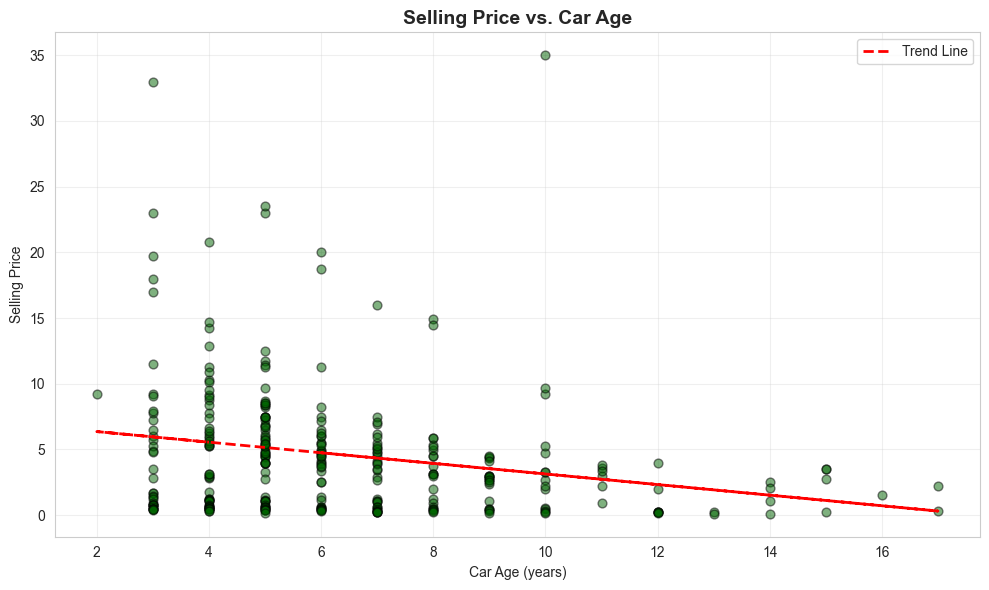


Correlation (car_age vs selling_price): -0.234

 Strong negative correlation expected — older cars depreciate significantly.


In [11]:

if 'car_age' in df_clean.columns and 'selling_price' in df_clean.columns:
    plt.figure(figsize=(10, 6))
    plt.scatter(df_clean['car_age'], df_clean['selling_price'],
                alpha=0.5, c='darkgreen', edgecolors='black', s=40)
    plt.title('Selling Price vs. Car Age', fontsize=14, fontweight='bold')
    plt.xlabel('Car Age (years)')
    plt.ylabel('Selling Price')

    z = np.polyfit(df_clean['car_age'], df_clean['selling_price'], 1)
    p = np.poly1d(z)
    plt.plot(df_clean['car_age'], p(df_clean['car_age']), "r--", linewidth=2, label='Trend Line')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    corr = df_clean['car_age'].corr(df_clean['selling_price'])
    print(f"\nCorrelation (car_age vs selling_price): {corr:.3f}")
    print("\n Strong negative correlation expected — older cars depreciate significantly.")
else:
    print(" Required columns not found.")

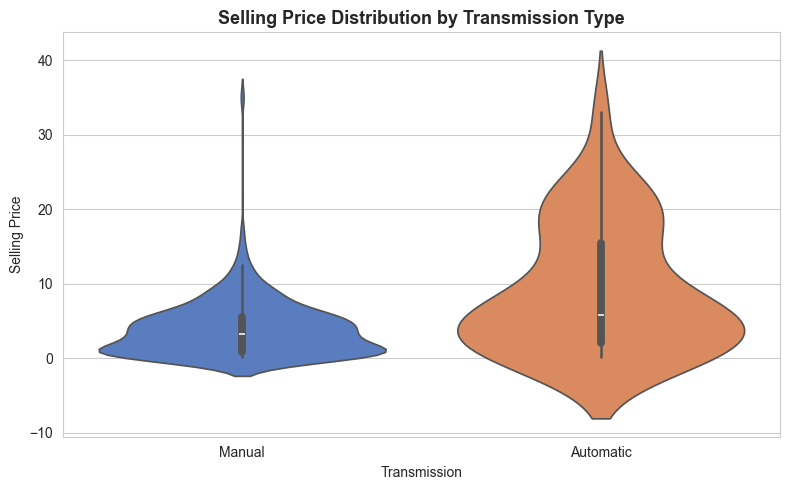

=== AVG PRICE BY TRANSMISSION ===
              mean  median  count
transmission                     
Automatic      9.0     6.0     39
Manual         4.0     3.0    260

 Automatic transmission cars typically command higher resale value.


In [12]:

if 'transmission' in df_clean.columns and 'selling_price' in df_clean.columns:
    plt.figure(figsize=(8, 5))
    sns.violinplot(data=df_clean, x='transmission', y='selling_price', palette='muted')
    plt.title('Selling Price Distribution by Transmission Type', fontsize=13, fontweight='bold')
    plt.xlabel('Transmission')
    plt.ylabel('Selling Price')
    plt.tight_layout()
    plt.show()
    
    print("=== AVG PRICE BY TRANSMISSION ===")
    print(df_clean.groupby('transmission')['selling_price'].agg(['mean', 'median', 'count']).round(0))
    
    print("\n Automatic transmission cars typically command higher resale value.")
else:
    print(" Required columns not found.")

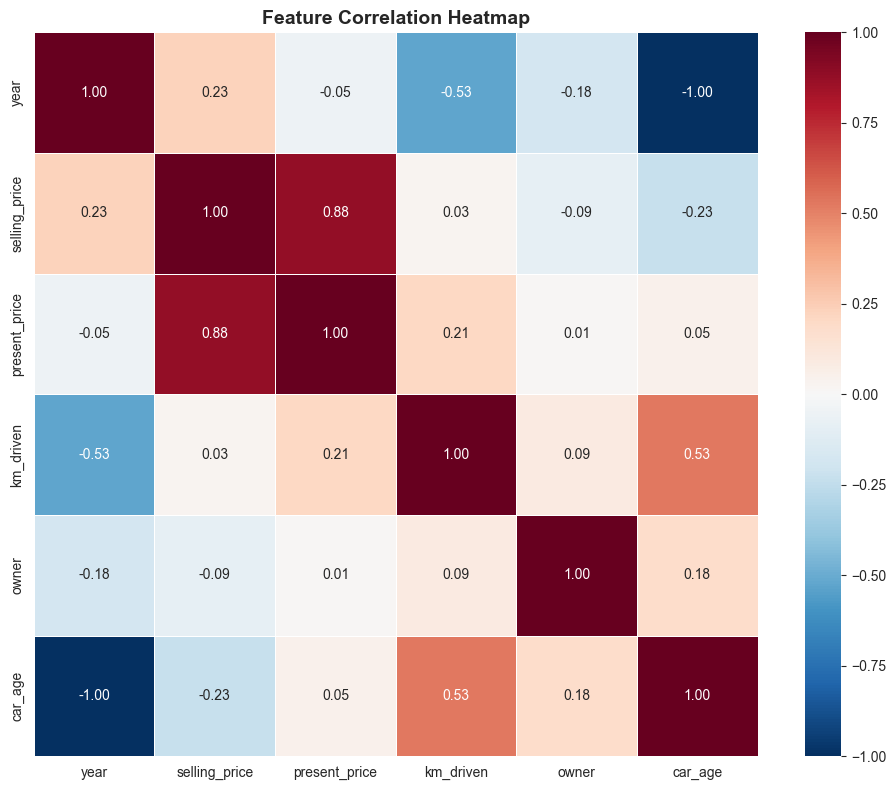


=== CORRELATIONS WITH SELLING PRICE ===
   present_price: 0.876
   year: 0.234
   car_age: -0.234
   owner: -0.088
   km_driven: 0.029

 Features most correlated with price will be strongest predictors.


In [13]:

numeric_df = df_clean.select_dtypes(include=[np.number])

if len(numeric_df.columns) >= 2:
    corr_matrix = numeric_df.corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap='RdBu_r',
        center=0,
        fmt='.2f',
        square=True,
        linewidths=0.5
    )
    plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    if 'selling_price' in corr_matrix.columns:
        price_corr = corr_matrix['selling_price'].drop('selling_price').sort_values(key=abs, ascending=False)
        print("\n=== CORRELATIONS WITH SELLING PRICE ===")
        for feature, corr in price_corr.items():
            print(f"   {feature}: {corr:.3f}")
    
    print("\n Features most correlated with price will be strongest predictors.")
else:
    print(" Not enough numeric columns for correlation heatmap.")

In [14]:

df_model = df_clean.copy()

cat_cols = [c for c in df_model.select_dtypes(include=['object']).columns
            if c not in ['car_name']] 

print(f"Categorical columns to encode: {cat_cols}")

df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

print(f"\nShape before encoding: {df_model.shape}")
print(f"Shape after encoding:  {df_encoded.shape}")

if 'car_name' in df_encoded.columns:
    df_encoded = df_encoded.drop('car_name', axis=1)

print(f"\nFinal modeling columns ({len(df_encoded.columns)}):")
print(df_encoded.columns.tolist())


Categorical columns to encode: ['fuel_type', 'seller_type', 'transmission', 'brand']

Shape before encoding: (299, 11)
Shape after encoding:  (299, 54)

Final modeling columns (53):
['year', 'selling_price', 'present_price', 'km_driven', 'owner', 'car_age', 'fuel_type_Diesel', 'fuel_type_Petrol', 'seller_type_Individual', 'transmission_Manual', 'brand_Activa', 'brand_Alto', 'brand_Amaze', 'brand_Bajaj', 'brand_Baleno', 'brand_Brio', 'brand_Camry', 'brand_Ciaz', 'brand_City', 'brand_Corolla', 'brand_Creta', 'brand_Dzire', 'brand_Elantra', 'brand_Eon', 'brand_Ertiga', 'brand_Etios', 'brand_Fortuner', 'brand_Grand', 'brand_Hero', 'brand_Honda', 'brand_Hyosung', 'brand_I10', 'brand_I20', 'brand_Ignis', 'brand_Innova', 'brand_Jazz', 'brand_Ktm', 'brand_Land', 'brand_Mahindra', 'brand_Omni', 'brand_Ritz', 'brand_Royal', 'brand_S', 'brand_Suzuki', 'brand_Swift', 'brand_Sx4', 'brand_Tvs', 'brand_Um', 'brand_Verna', 'brand_Vitara', 'brand_Wagon', 'brand_Xcent', 'brand_Yamaha']


In [15]:

if 'selling_price' in df_encoded.columns:
    X = df_encoded.drop('selling_price', axis=1)
    y = df_encoded['selling_price']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    print(f"Features (X): {X.shape[1]} columns")
    print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
    print(f"Test set:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print("\n Data split and scaled successfully.")
else:
    print(" 'selling_price' not found in encoded data.")

Features (X): 52 columns
Training set: 239 samples (80%)
Test set:     60 samples (20%)

 Data split and scaled successfully.


In [17]:

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

print("=== TRAINING MODELS ===\n")

for name, model in models.items():
    if name == 'Linear Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'model': model,
        'predictions': y_pred,
        'mae': mae,
        'rmse': rmse,
        'r2': r2
    }
    
    print(f" {name}")
    print(f"   MAE:  ₹{mae:,.0f}")
    print(f"   RMSE: ₹{rmse:,.0f}")
    print(f"   R²:   {r2:.4f}")
    print()



=== TRAINING MODELS ===

 Linear Regression
   MAE:  ₹2
   RMSE: ₹3
   R²:   0.5517

 Random Forest
   MAE:  ₹1
   RMSE: ₹4
   R²:   0.5108

 Gradient Boosting
   MAE:  ₹1
   RMSE: ₹3
   R²:   0.6834



=== MODEL COMPARISON ===
            Model      MAE     RMSE       R²
Gradient Boosting 1.185669 2.856611 0.683384
Linear Regression 1.808783 3.399321 0.551652
    Random Forest 1.429775 3.550917 0.510772


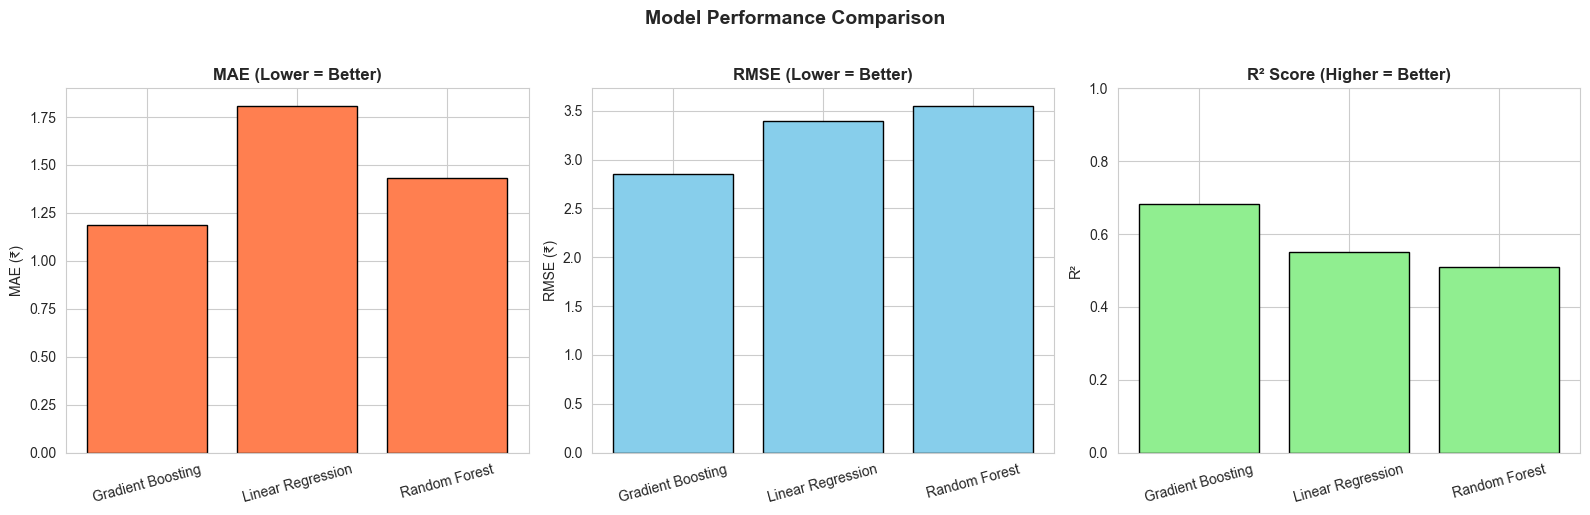


 BEST MODEL: Gradient Boosting (R² = 0.6834)


In [18]:

comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'MAE': [results[m]['mae'] for m in results.keys()],
    'RMSE': [results[m]['rmse'] for m in results.keys()],
    'R²': [results[m]['r2'] for m in results.keys()]
})


comparison = comparison.sort_values('R²', ascending=False)

print("=== MODEL COMPARISON ===")
print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(comparison['Model'], comparison['MAE'], color='coral', edgecolor='black')
axes[0].set_title('MAE (Lower = Better)', fontweight='bold')
axes[0].set_ylabel('MAE (₹)')

axes[1].bar(comparison['Model'], comparison['RMSE'], color='skyblue', edgecolor='black')
axes[1].set_title('RMSE (Lower = Better)', fontweight='bold')
axes[1].set_ylabel('RMSE (₹)')

axes[2].bar(comparison['Model'], comparison['R²'], color='lightgreen', edgecolor='black')
axes[2].set_title('R² Score (Higher = Better)', fontweight='bold')
axes[2].set_ylabel('R²')
axes[2].set_ylim(0, 1)

for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

best_model_name = comparison.iloc[0]['Model']
best_r2 = comparison.iloc[0]['R²']
print(f"\n BEST MODEL: {best_model_name} (R² = {best_r2:.4f})")

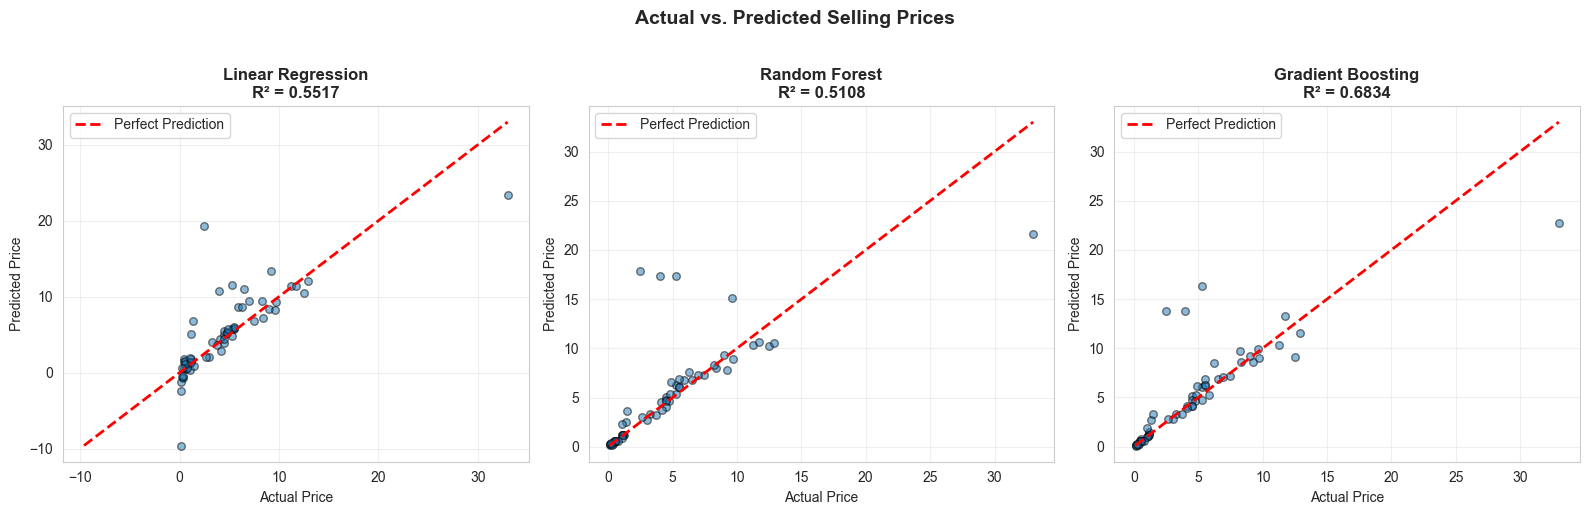

In [19]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (name, result) in enumerate(results.items()):
    y_pred = result['predictions']
    
    axes[idx].scatter(y_test, y_pred, alpha=0.5, edgecolors='black', s=30)

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    axes[idx].set_xlabel('Actual Price')
    axes[idx].set_ylabel('Predicted Price')
    axes[idx].set_title(f'{name}\nR² = {result["r2"]:.4f}', fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Actual vs. Predicted Selling Prices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


=== TOP 15 FEATURE (Gradient Boosting) ===
            Feature  Importance
      present_price    0.873875
               year    0.044804
            car_age    0.033833
         brand_Land    0.024410
          km_driven    0.008690
transmission_Manual    0.004917
   fuel_type_Petrol    0.004611
   fuel_type_Diesel    0.003120
        brand_Verna    0.000492
     brand_Fortuner    0.000149
      brand_Corolla    0.000142
         brand_Jazz    0.000126
        brand_Creta    0.000125
        brand_Amaze    0.000099
          brand_I10    0.000092


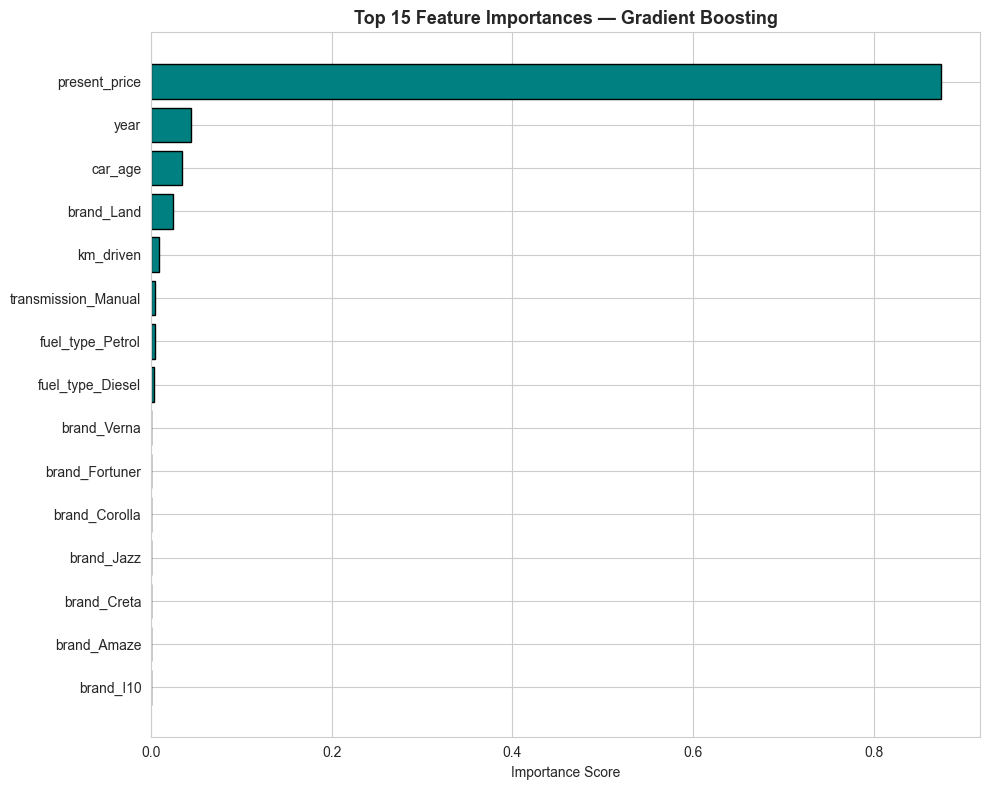


 present_price is the most important predictor of car price.


In [20]:

best_model = results[best_model_name]['model']
feature_names = X.columns.tolist()

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    
    feat_imp = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print(f"=== TOP 15 FEATURE ({best_model_name}) ===")
    print(feat_imp.head(15).to_string(index=False))

    top_n = min(15, len(feat_imp))
    plt.figure(figsize=(10, 8))
    plt.barh(range(top_n), feat_imp['Importance'].head(top_n), color='teal', edgecolor='black')
    plt.yticks(range(top_n), feat_imp['Feature'].head(top_n))
    plt.xlabel('Importance Score')
    plt.title(f'Top {top_n} Feature Importances — {best_model_name}', fontsize=13, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
elif hasattr(best_model, 'coef_'):

    coefs = np.abs(best_model.coef_)
    
    feat_imp = pd.DataFrame({
        'Feature': feature_names,
        'Abs_Coefficient': coefs
    }).sort_values('Abs_Coefficient', ascending=False)
    
    print(f"=== TOP 15 FEATURE COEFFICIENTS ({best_model_name}) ===")
    print(feat_imp.head(15).to_string(index=False))
    
    top_n = min(15, len(feat_imp))
    plt.figure(figsize=(10, 8))
    plt.barh(range(top_n), feat_imp['Abs_Coefficient'].head(top_n), color='orange', edgecolor='black')
    plt.yticks(range(top_n), feat_imp['Feature'].head(top_n))
    plt.xlabel('Absolute Coefficient')
    plt.title(f'Top {top_n} Feature Coefficients — {best_model_name}', fontsize=13, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

print(f"\n {feat_imp.iloc[0]['Feature']} is the most important predictor of car price.")

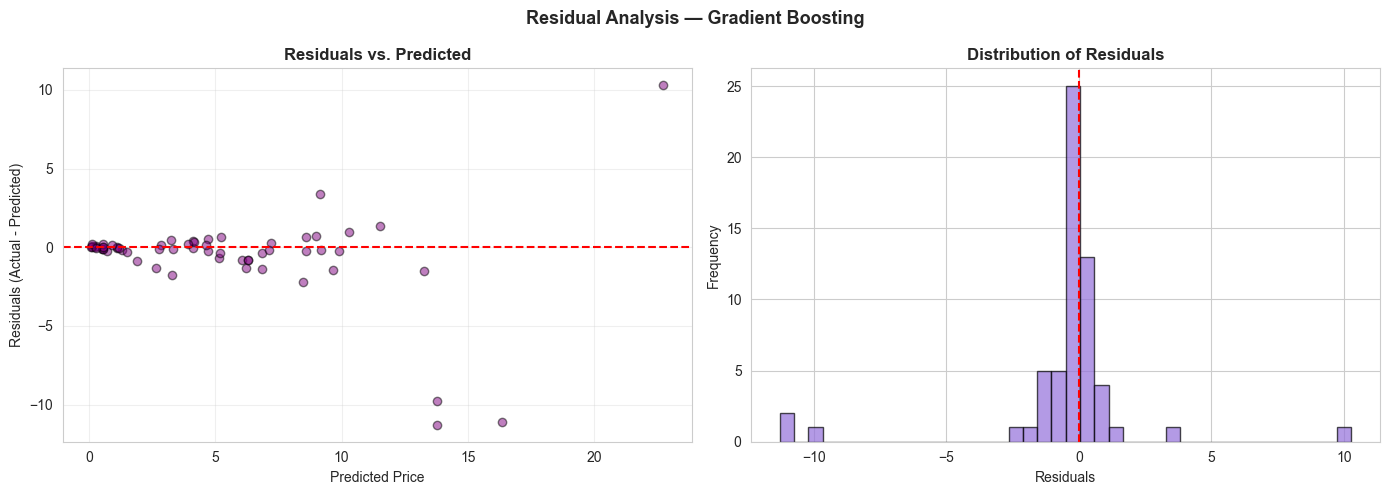

Mean residual: ₹-0
Residual std:  ₹3


In [21]:

y_pred_best = results[best_model_name]['predictions']
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_best, residuals, alpha=0.5, edgecolors='black', color='purple')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residuals (Actual - Predicted)')
axes[0].set_title('Residuals vs. Predicted', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals, bins=40, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals', fontweight='bold')
axes[1].axvline(x=0, color='red', linestyle='--')

plt.suptitle(f'Residual Analysis — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mean residual: ₹{residuals.mean():,.0f}")
print(f"Residual std:  ₹{residuals.std():,.0f}")

In [23]:

print("=== SAMPLE PREDICTION ===\n")

sample = pd.DataFrame(0, index=[0], columns=X.columns)

if 'year' in sample.columns:
    sample['year'] = 2015
if 'car_age' in sample.columns:
    sample['car_age'] = 5
if 'km_driven' in sample.columns:
    sample['km_driven'] = 50000
if 'present_price' in sample.columns:
    sample['present_price'] = 800000

for col in sample.columns:
    if 'brand_Maruti' in col:
        sample[col] = 1
    elif 'fuel_type_Petrol' in col:
        sample[col] = 1
    elif 'transmission_Manual' in col:
        sample[col] = 1
    elif 'seller_type_Individual' in col:
        sample[col] = 1

print("Sample car: 2015 Maruti, Petrol, Manual, 50,000 km driven")

if best_model_name == 'Linear Regression':
    sample_scaled = scaler.transform(sample)
    predicted_price = best_model.predict(sample_scaled)[0]
else:
    predicted_price = best_model.predict(sample)[0]

print(f"\n Predicted Selling Price: ₹{predicted_price:,.0f}")

std_residual = residuals.std()
print(f"   Approximate range: ₹{predicted_price - 1.96*std_residual:,.0f} — ₹{predicted_price + 1.96*std_residual:,.0f}")

=== SAMPLE PREDICTION ===

Sample car: 2015 Maruti, Petrol, Manual, 50,000 km driven

 Predicted Selling Price: ₹23
   Approximate range: ₹17 — ₹28
